## Time Series

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.stattools import adfuller

plt.style.use('default')

### Exploring

In [77]:
df = pd.read_csv('exchange_rate.csv')

In [78]:
df.dtypes

date           str
Ex_rate    float64
dtype: object

In [79]:
#Converting str to standard data-time format
df['date'] = pd.to_datetime(df['date'], dayfirst=True)
df = df.sort_values('date')
df.set_index('date', inplace=True)

In [80]:
df.head()

,Ex_rate
date,
1990-01-01,0.7855
1990-01-02,0.7818
1990-01-03,0.7867
1990-01-04,0.7860
1990-01-05,0.7849


In [81]:
df.isnull().sum()

Ex_rate    0
dtype: int64

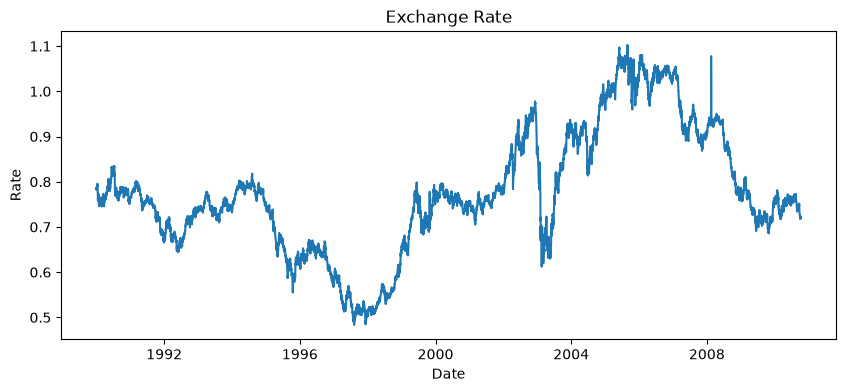

In [82]:
plt.figure(figsize=(10,4))
plt.plot(df.index, df['Ex_rate'])
plt.title('Exchange Rate')
plt.xlabel('Date')
plt.ylabel('Rate')
plt.show()

* The exchange rate fluctuates throughout the entire period, indicating continuous changes over time.
* A downward trend is observed from 1990 to around 1997, where the exchange rate reaches its lowest level.
* From 1998 onwards, the exchange rate increases steadily and reaches its peak between 2005 and 2007.
* A sharp decline around 2003 is followed by a rapid recovery, showing a period of high volatility.
* Around 2008, the exchange rate experiences a noticeable spike before gradually decreasing.
* Towards the end of the dataset, the exchange rate remains relatively stable with moderate fluctuations between 0.70 and 0.80.
* No clear seasonal pattern is visible, but the data exhibits an overall changing trend with irregular fluctuations.


### Train-Test Split

In [83]:
train_size = int(len(df)*0.8) #80%
train_size

6070

In [84]:
train = df['Ex_rate'][:train_size]
test = df['Ex_rate'][train_size:]

### ARIMA Model

In [96]:
#ADF test for d value
result = adfuller(df['Ex_rate'])
print("ADF Statistic:", result[0])
print("p-value:", result[1])

if result[1] < 0.05:
    d=0
    print("The series is stationary (d = 0)")
else:
    d=1
    print("The series is non-stationary (d = 1)")

ADF Statistic: -1.6649941807381419
p-value: 0.4492327353597959
The series is non-stationary (d = 1)


* If p-value < 0.05 → series is stationary, so d = 0.
* Otherwise → first differencing is required, so d = 1.

<Figure size 1000x400 with 0 Axes>

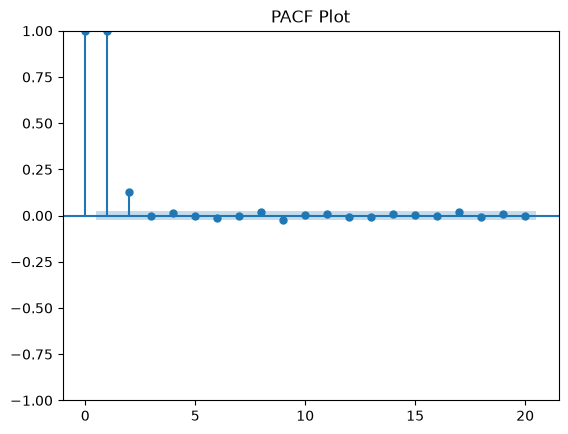

In [ ]:
#PACF for p value
plt.figure(figsize=(10, 4))
plot_pacf(df['Ex_rate'], lags=20)
plt.title("PACF Plot")
plt.show()

The PACF plot shows a strong and significant spike at lag 1, while the remaining lags are close to zero and do not show significant partial autocorrelation. Therefore, the initial autoregressive parameter is chosen as **p = 1**.

In [93]:
p=1

<Figure size 1000x400 with 0 Axes>

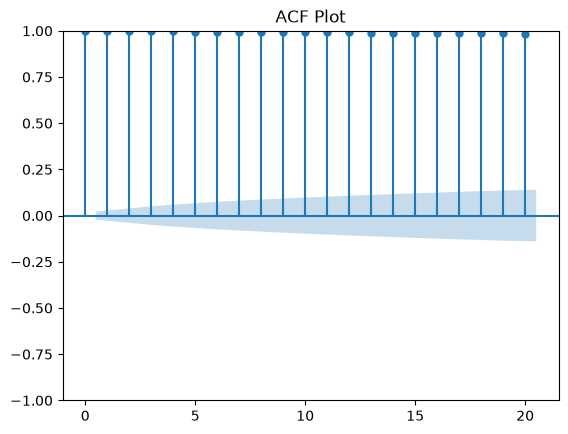

In [ ]:
#ACF for 1 value
plt.figure(figsize=(10, 4))
plot_acf(df['Ex_rate'], lags=20)
plt.title("ACF Plot")
plt.show()

The ACF plot shows strong positive autocorrelation across multiple lags, indicating that the time series is non-stationary. This is consistent with the ADF test result, where the p-value is greater than 0.05. As an initial model, the moving average parameter is chosen as **q = 1**, which can be further refined based on model performance.

In [94]:
q=1

In [97]:
arima_model = ARIMA(train, order=(p,d,q))
arima_fit = arima_model.fit()
print(arima_fit.summary())

c:\Users\Videep\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\Videep\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\Videep\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                Ex_rate   No. Observations:                 6070
Model:                 ARIMA(1, 1, 1)   Log Likelihood               22719.046
Date:                Fri, 24 Jul 2026   AIC                         -45432.092
Time:                        21:27:19   BIC                         -45411.959
Sample:                    01-01-1990   HQIC                        -45425.104
                         - 08-14-2006                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5972      0.062     -9.648      0.000      -0.719      -0.476
ma.L1          0.5398      0.064      8.430      0.000       0.414       0.665
sigma2      3.281e-05   1.95e-07    168.198      0.0

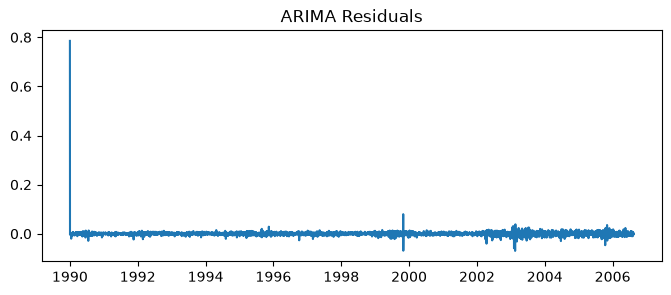

In [86]:
residuals = arima_fit.resid
plt.figure(figsize=(8,3))
plt.plot(residuals)
plt.title('ARIMA Residuals')
plt.show()

- Most of the residual values are centered around zero, indicating that the ARIMA model has captured the overall pattern in the exchange rate data.
- The residuals appear to fluctuate randomly without any clear upward or downward trend, suggesting that no significant pattern remains unexplained.
- A few large spikes are observed, particularly near the beginning of the series and at a few later time points, indicating occasional prediction errors or unusual observations.
- The spread of the residuals remains relatively small for most of the time period, showing that the model's prediction errors are generally low.

In [98]:
arima_forecast = arima_fit.forecast(steps=len(test))

In [99]:
comparison = pd.DataFrame({'Actual': test,'Predicted': arima_forecast})
print(comparison.head())

              Actual  Predicted
2006-08-15  1.025347   1.023685
2006-08-16  1.026905   1.023606
2006-08-17  1.037344   1.023653
2006-08-18  1.038875   1.023625
2006-08-19  1.032855   1.023642


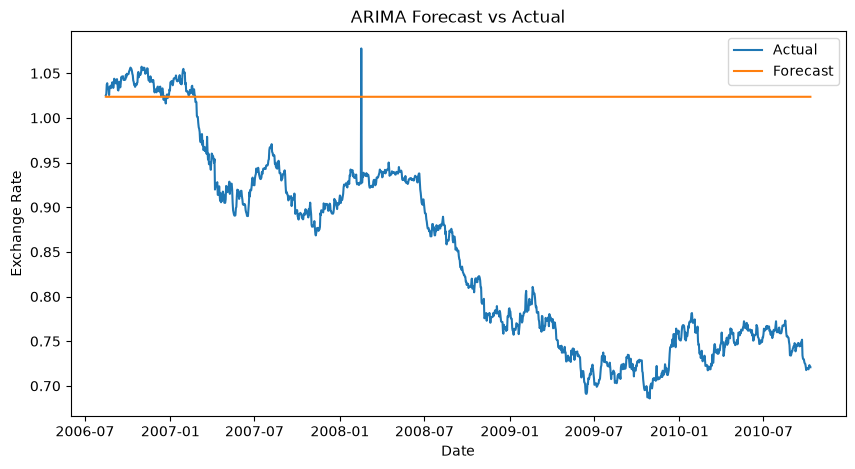

In [100]:
plt.figure(figsize=(10,5))
plt.plot(test.index, test, label='Actual')
plt.plot(test.index, arima_forecast, label='Forecast')
plt.title('ARIMA Forecast vs Actual')
plt.xlabel('Date')
plt.ylabel('Exchange Rate')
plt.legend()
plt.show()

The ARIMA model generates an almost constant forecast throughout the test period. While the model captures the overall average level of the exchange rate, it does not follow the fluctuations observed in the actual data. This suggests that the selected ARIMA(1,1,1) model is not able to fully capture the underlying time series pattern and that alternative parameter values may improve forecasting performance.

### Exponential Smoothing

In [ ]:
#Since data has a trend but no seasonality we choose Holt's Linear
exp_model = ExponentialSmoothing(train,trend='add',seasonal=None) #Holt's Linear Model Conditions
exp_fit = exp_model.fit(optimized=True)
#The model parameters were optimized using the built-in optimization (optimized=True) provided by the 
#Statsmodels library.
print(exp_fit.summary())

                       ExponentialSmoothing Model Results                       
Dep. Variable:                  Ex_rate   No. Observations:                 6070
Model:             ExponentialSmoothing   SSE                              0.199
Optimized:                         True   AIC                         -62655.663
Trend:                         Additive   BIC                         -62628.819
Seasonal:                          None   AICC                        -62655.650
Seasonal Periods:                  None   Date:                 Fri, 24 Jul 2026
Box-Cox:                          False   Time:                         21:37:40
Box-Cox Coeff.:                    None                                         
                       coeff                 code              optimized      
------------------------------------------------------------------------------
smoothing_level            0.9428890                alpha                 True
smoothing_trend             0.0000

c:\Users\Videep\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [105]:
exp_forecast = exp_fit.forecast(len(test))

In [106]:
exp_comparison = pd.DataFrame({'Actual': test,'Predicted': exp_forecast})

In [107]:
exp_comparison.head()

,Actual,Predicted
2006-08-15,1.025347,1.023582
2006-08-16,1.026905,1.023621
2006-08-17,1.037344,1.023661
2006-08-18,1.038875,1.023700
2006-08-19,1.032855,1.023739


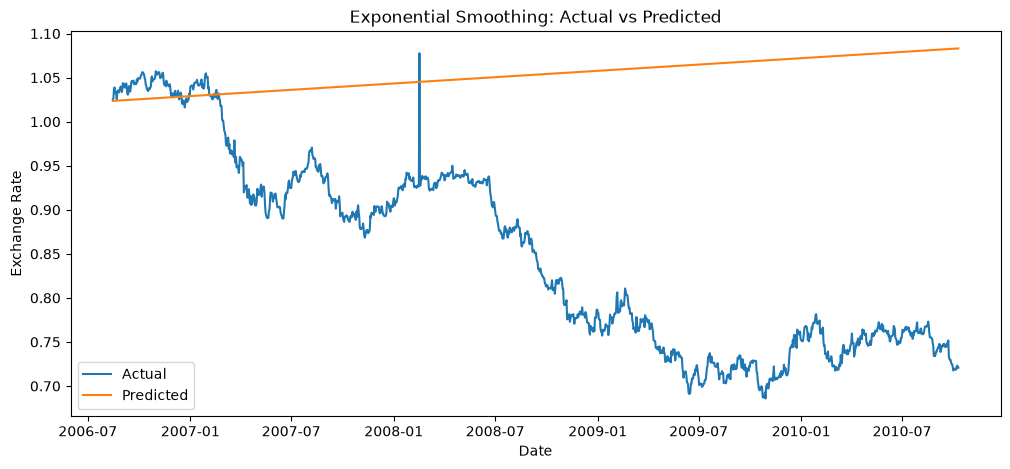

In [108]:
plt.figure(figsize=(12,5))
plt.plot(test.index, test, label='Actual')
plt.plot(test.index, exp_forecast, label='Predicted')
plt.title("Exponential Smoothing: Actual vs Predicted")
plt.xlabel("Date")
plt.ylabel("Exchange Rate")
plt.legend()
plt.show()

### Evaluation

In [109]:
# ARIMA Metrics
arima_mae = mean_absolute_error(test, arima_forecast)
arima_rmse = np.sqrt(mean_squared_error(test, arima_forecast))
arima_mape = np.mean(np.abs((test - arima_forecast) / test)) * 100

# Exponential Smoothing Metrics
exp_mae = mean_absolute_error(test, exp_forecast)
exp_rmse = np.sqrt(mean_squared_error(test, exp_forecast))
exp_mape = np.mean(np.abs((test - exp_forecast) / test)) * 100

In [110]:
# Comparison Table
comparison = pd.DataFrame({
    'Model': ['ARIMA', 'Exponential Smoothing'],
    'MAE': [arima_mae, exp_mae],
    'RMSE': [arima_rmse, exp_rmse],
    'MAPE (%)': [arima_mape, exp_mape]
})

In [112]:
comparison = comparison.round(4)
comparison

,Model,MAE,RMSE,MAPE (%)
0,ARIMA,0.1777,0.2054,22.7980
1,Exponential Smoothing,0.2066,0.2391,26.5087


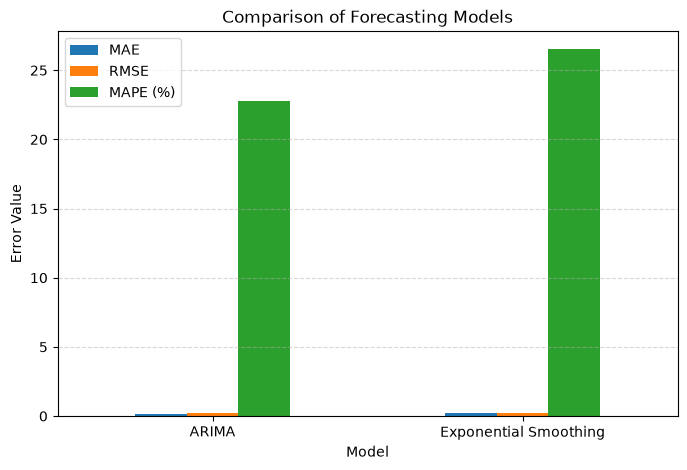

In [ ]:
comparison.set_index('Model').plot(kind='bar',figsize=(8,5))
plt.title('Comparison of Forecasting Models')
plt.ylabel('Error Value')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

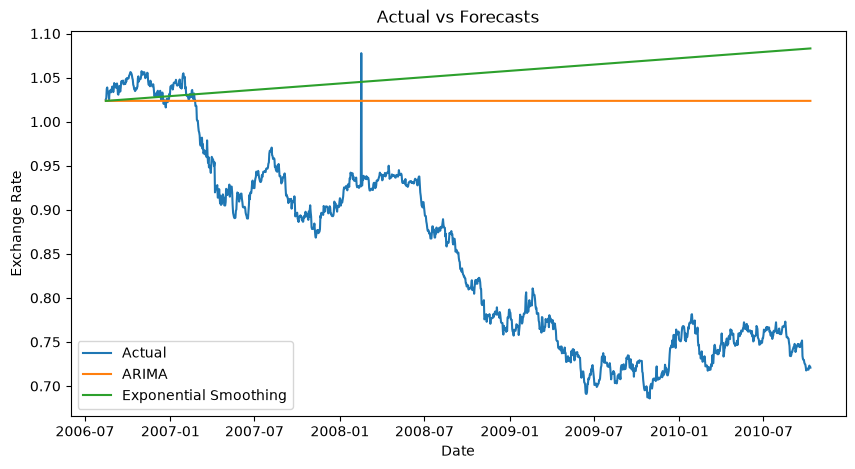

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(test.index, test, label='Actual')
plt.plot(test.index, arima_forecast, label='ARIMA')
plt.plot(test.index, exp_forecast, label='Exponential Smoothing')
plt.title("Actual vs Forecasts")
plt.xlabel("Date")
plt.ylabel("Exchange Rate")
plt.legend()
plt.show()

* The actual exchange rate shows a downward trend with several fluctuations over the test period.
* The ARIMA forecast remains almost constant and does not capture the declining pattern observed in the actual data.
* The Exponential Smoothing forecast predicts a gradual upward trend, which also does not match the movement of the actual exchange rate.
* Both models fail to capture the sudden changes and short-term fluctuations present in the exchange rate series.
* Based on the forecast plot, neither model closely follows the actual exchange rate, indicating limited forecasting accuracy for this dataset.

### Conclusion

The comparison table showed that ARIMA has lower MAE, RMSE, and MAPE than Exponential Smoothing, we can conclude that ARIMA performs better numerically, even though both forecasts deviate considerably from the actual values.